In [1]:
!git config --global user.email "silasschack@hotmail.com"
!git config --global user.name "SilasSchack"

In [2]:
pip install pymatgen

In [3]:
pip install matgl

In [4]:
path = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D/data/final/MP"
path_red = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D"
path = r"/content/ML_Personal_git"
path_red = r"/content/ML_Personal_git"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pymatgen.core import Structure
import matgl
from matgl.ext.pymatgen import Structure2Graph

import networkx as nx
import matplotlib.pyplot as plt
from pymatgen.core import Element

import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

In [30]:
  !git clone https://github.com/SSBNS/ML_Personal_git.git
  !git clone https://github.com/aimat-lab/3DSC.git

fatal: destination path 'ML_Personal_git' already exists and is not an empty directory.
Cloning into '3DSC'...
remote: Enumerating objects: 16088, done.
remote: Counting objects: 100% (257/257), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 16088 (delta 134), reused 168 (delta 78), pack-reused 15831 (from 1)
Receiving objects: 100% (16088/16088), 11.73 MiB | 26.23 MiB/s, done.
Resolving deltas: 100% (9300/9300), done.


In [6]:
data_only_id = pd.read_csv("/content/ML_Personal_git/3DSC_ICSD_only_IDs.csv", skiprows=1)
data = pd.read_csv("/content/ML_Personal_git/3DSC_ICSD.csv", skiprows=1)
cif_ex = pd.read_csv("/content/ML_Personal_git/ex_cifs.csv", skiprows=0)
#print(data.columns)
print(data.loc[0,'tc'])

1.128


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/cifs.zip", 'r') as z:
    z.extractall("/content/cifs")

Mounted at /content/drive


In [8]:
import numpy as np
from pymatgen.analysis.local_env import VoronoiNN, LocalStructOrderParams
from pymatgen.analysis.bond_valence import BVAnalyzer

MAX_Z = 94
ALL_ELEMENTS = list(range(1, MAX_Z+1))  # Z = 1 to 94, adjust to your dataset

def one_hot_element(elem, all_z=ALL_ELEMENTS):
    z = int(elem.Z)
    return [1.0 if z == z_i else 0.0 for z_i in all_z]

# ─── Oxidation-state decoration (best-effort) ────────────────────────────────

def try_decorate_oxidation(structure):
    """Try to assign oxidation states via bond-valence analysis.
    Returns the decorated structure, or the original if it fails."""
    try:
        bv = BVAnalyzer()
        return bv.get_oxi_state_decorated_structure(structure)
    except Exception:
        return structure


# ─── Local environment analysis (best-effort) ────────────────────────────────

def compute_local_env(structure):
    """
    Returns per-site dicts with:
      - coordination_number  (float)
      - order_params         (list of 5 floats: cn, tet, oct, sq, bent)
      - voronoi_volume       (float)
      - mean_solid_angle     (float)
      - std_solid_angle      (float)
      - mean_face_area       (float)
    Falls back to zeros on failure.
    """
    n = len(structure)
    zero_env = {
        "coordination_number": 0.0,
        "order_params":        [0.0] * 5,
        "voronoi_volume":      0.0,
        "mean_solid_angle":    0.0,
        "std_solid_angle":     0.0,
        "mean_face_area":      0.0,
    }

    try:
        vnn   = VoronoiNN(compute_adj_neighbors=False)
        lsop  = LocalStructOrderParams(["cn", "tet", "oct", "sq", "bent"])
        results = []

        for i in range(n):
            try:
                poly  = vnn.get_voronoi_polyhedra(structure, i)  # {site: stats_dict}
                stats = list(poly.values())

                cn           = float(len(stats))
                solid_angles = np.array([s["solid_angle"] for s in stats])
                face_areas   = np.array([s["area"]        for s in stats])
                volume       = float(sum(s["volume"] for s in stats))

                op = lsop.get_order_parameters(structure, i)
                op = [v if v is not None else 0.0 for v in op]

                results.append({
                    "coordination_number": cn,
                    "order_params":        op,
                    "voronoi_volume":      volume,
                    "mean_solid_angle":    float(solid_angles.mean()),
                    "std_solid_angle":     float(solid_angles.std()),
                    "mean_face_area":      float(face_areas.mean()),
                })
            except Exception:
                results.append(zero_env.copy())

        return results

    except Exception:
        return [zero_env.copy() for _ in range(n)]


# ─── Per-element scalar features ─────────────────────────────────────────────

def _elem_features_Z(elem):
    """Extract scalar features from a pymatgen Element/Species object.
    All values are cast to float; missing values become 0.0."""
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state (present only on Species, not bare Element)
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range (proxy for chemical versatility)
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    return [
        # Identity
        safe(elem.Z),                       # atomic number
        safe(elem.atomic_mass),             # atomic mass  (u)
        # Size
        safe(elem.atomic_radius),           # atomic radius (Å)
        safe(elem.average_ionic_radius),    # avg ionic radius (Å)
        # Chemistry
        safe(elem.X),                       # Pauling electronegativity
        safe(elem.max_oxidation_state),     # max ox. state
        safe(elem.min_oxidation_state),     # min ox. state
        ox,                                 # assigned ox. state (0 if unknown)
        ox_range,                           # ox. state range

    ]

# Total length of _elem_features output — update if you add/remove entries
N_ELEM_FEATURES = 9

def _elem_features(elem):
    """Extract scalar features from a pymatgen Element/Species object.
    All values are cast to float; missing values become 0.0."""
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state (present only on Species, not bare Element)
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range (proxy for chemical versatility)
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    return [
        # Identity
        # safe(elem.Z),                       # atomic number
        *one_hot_element(elem),     # e.g. 94 binary features for element identity
        safe(elem.atomic_mass),             # atomic mass  (u)
        # Size
        safe(elem.atomic_radius),           # atomic radius (Å)
        safe(elem.average_ionic_radius),    # avg ionic radius (Å)
        # Chemistry
        safe(elem.X),                       # Pauling electronegativity
        safe(elem.max_oxidation_state),     # max ox. state
        safe(elem.min_oxidation_state),     # min ox. state
        ox,                                 # assigned ox. state (0 if unknown)
        ox_range,                           # ox. state range

    ]

def _elem_features(elem):
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    # Valence electron count
    try:
        valence_electrons = float(sum(elem.valence))
    except Exception:
        valence_electrons = 0.0

    # d-electron count (from electronic structure string e.g. '[Ar] 3d5 4s1')
    try:
        d_electrons = float(elem.full_electronic_structure[-1][2]
                           if elem.full_electronic_structure[-1][1] == 'd'
                           else next((n for _, shell, n in elem.full_electronic_structure
                                     if shell == 'd'), 0))
    except Exception:
        d_electrons = 0.0

    # Block flags
    try:
        is_d_block = 1.0 if elem.block == 'd' else 0.0
        is_f_block = 1.0 if elem.block == 'f' else 0.0
    except Exception:
        is_d_block, is_f_block = 0.0, 0.0

    # Molar volume
    try:
        molar_volume = safe(elem.molar_volume)
    except Exception:
        molar_volume = 0.0

    # Mendeleev number
    try:
        mendeleev_no = safe(elem.mendeleev_no)
    except Exception:
        mendeleev_no = 0.0

    return [
        # Identity
        *one_hot_element(elem),         # 94 one-hot
        safe(elem.atomic_mass),         # atomic mass (u)
        # Size
        safe(elem.atomic_radius),       # atomic radius (Å)
        safe(elem.average_ionic_radius),# avg ionic radius (Å)
        molar_volume,                   # molar volume
        # Chemistry
        safe(elem.X),                   # Pauling electronegativity
        safe(elem.max_oxidation_state), # max ox. state
        safe(elem.min_oxidation_state), # min ox. state
        ox,                             # assigned ox. state
        ox_range,                       # ox. state range
        valence_electrons,              # total valence electrons
        d_electrons,                    # d-electron count
        is_d_block,                     # d-block flag
        is_f_block,                     # f-block flag
        mendeleev_no,                   # Mendeleev number
    ]

# Total: 94 (one-hot) + 14 (scalar) = 108 elemental features
N_ELEM_FEATURES = MAX_Z + 14

# N_ELEM_FEATURES = MAX_Z + 8


# ─── Main feature builder ─────────────────────────────────────────────────────

def get_atom_features_hot_env(structure):
    """
    Build a node feature matrix for `structure`.

    Feature layout (per node):
│ Elemental features (one-hot + scalar) │ 108    │
│ Occupancy                             │   1    │
│ Site disorder                         │   1    │
│ Fractional coordinates                │   3    │
│ Coordination number                   │   1    │
│ Order params                          │   5    │
│ Voronoi volume + angles + area        │   4    │
├───────────────────────────────────────┼────────┤
│ Total                                 │ 123    │

    Returns
    -------
    np.ndarray of shape (n_sites, 33), dtype float32
    """
    # Best-effort oxidation-state decoration
    structure = try_decorate_oxidation(structure)

    # Pre-compute local environment for all sites
    local_env = compute_local_env(structure)

    features = []

    for i, site in enumerate(structure):
        env = local_env[i]

        # ── Structural / site descriptors (same for ordered & disordered) ──
        frac    = list(site.frac_coords)                          # (3,)
        cn      = [env["coordination_number"]]                    # (1,)
        op      = env["order_params"]                             # (5,)
        voro    = [
            env["voronoi_volume"],
            env["mean_solid_angle"],
            env["std_solid_angle"],
            env["mean_face_area"],
        ]                                                         # (4,)

        # ── Elemental descriptors ──────────────────────────────────────────
        if site.is_ordered:
            elem      = site.specie
            elem_feat = _elem_features(elem)
            occupancy = 1.0
            disorder  = 0.0

        else:
            # Weighted average of elemental features over species
            occupancies = list(site.species.values())
            disorder    = -sum(o * np.log(o + 1e-9) for o in occupancies)
            occupancy   = max(occupancies)

            elem_feat   = np.zeros(N_ELEM_FEATURES, dtype=np.float64)
            for elem, occ in site.species.items():
                elem_feat += occ * np.array(_elem_features(elem), dtype=np.float64)
            elem_feat = elem_feat.tolist()

        # ── Concatenate all blocks ─────────────────────────────────────────
        node = [
            *elem_feat,       # 18
            occupancy,        #  1
            disorder,         #  1
            *frac,            #  3
            *cn,              #  1
            *op,              #  5
            *voro,            #  4
        ]                     # = 33 total

        features.append(node)

    return np.array(features, dtype=np.float32)

In [9]:
def get_atom_features_hot_noenv(structure):
    """
    Build a node feature matrix for `structure`.

    Feature layout (per node):
│ Elemental features (one-hot + scalar) │ 108    │
│ Occupancy                             │   1    │
│ Site disorder                         │   1    │
│ Fractional coordinates                │   3    │
│ Coordination number                   │   1    │
│ Order params                          │   5    │
│ Voronoi volume + angles + area        │   4    │
├───────────────────────────────────────┼────────┤
│ Total                                 │ 123    │

    Returns
    -------
    np.ndarray of shape (n_sites, 33), dtype float32
    """
    # Best-effort oxidation-state decoration
    structure = try_decorate_oxidation(structure)

    # Pre-compute local environment for all sites
    # local_env = compute_local_env(structure)

    features = []

    for i, site in enumerate(structure):
        # env = local_env[i]

        # ── Structural / site descriptors (same for ordered & disordered) ──
        frac    = list(site.frac_coords)                          # (3,)
        # cn      = [env["coordination_number"]]                    # (1,)
        # op      = env["order_params"]                             # (5,)
        # voro    = [
        #     env["voronoi_volume"],
        #     env["mean_solid_angle"],
        #     env["std_solid_angle"],
        #     env["mean_face_area"],
        # ]                                                         # (4,)

        # ── Elemental descriptors ──────────────────────────────────────────
        if site.is_ordered:
            elem      = site.specie
            elem_feat = _elem_features(elem)
            occupancy = 1.0
            disorder  = 0.0

        else:
            # Weighted average of elemental features over species
            occupancies = list(site.species.values())
            disorder    = -sum(o * np.log(o + 1e-9) for o in occupancies)
            occupancy   = max(occupancies)

            elem_feat   = np.zeros(N_ELEM_FEATURES, dtype=np.float64)
            for elem, occ in site.species.items():
                elem_feat += occ * np.array(_elem_features(elem), dtype=np.float64)
            elem_feat = elem_feat.tolist()

        # ── Concatenate all blocks ─────────────────────────────────────────
        node = [
            *elem_feat,       # 18
            occupancy,        #  1
            disorder,         #  1
            *frac,            #  3
            # *cn,              #  1
            # *op,              #  5
            # *voro,            #  4
        ]                     # = 33 total

        features.append(node)

    return np.array(features, dtype=np.float32)

In [10]:
# Gaussian basis expansion for bond distances (like CGCNN)
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

def structure_to_graph_adaptive(structure, target,use_env=True):
    # Node features
    a, b, c = structure.lattice.abc
    cutoff = 1.5 * min(a, b, c)
    # cutoff = 8.0  # fixed, in Ångströms

    if use_env:
        atom_feats = get_atom_features_hot_env(structure)
    else:
        atom_feats = get_atom_features_hot_noenv(structure)

    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    # # After getting neighbors, optionally trim to closest N per site
    # MAX_NEIGHBORS = 12  # typical for close-packed metals

    # for i, neighbors in enumerate(all_neighbors):
    #     if len(neighbors) > MAX_NEIGHBORS:
    #         neighbors_sorted = sorted(neighbors, key=lambda x: x[1])  # sort by distance
    #         all_neighbors[i] = neighbors_sorted[:MAX_NEIGHBORS]

    # --- adaptive neighbour cutoff: 1.2 × nearest-neighbour distance ---
    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        if not neighbors:
            continue

        nearest_dist = min(nbr[1] for nbr in neighbors)
        adaptive_cutoff = 1.5 * nearest_dist

        for neighbor in neighbors:
            if neighbor[1] <= adaptive_cutoff:
                edge_src.append(i)
                edge_dst.append(neighbor[2])
                edge_distances.append(neighbor[1])

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

In [ ]:
data.loc[0,'cif']

In [ ]:
path =('/content/cifs/cifs/' + data.loc[0,'cif'].removeprefix('/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/'))
structure = Structure.from_file(path)
graph = structure_to_graph_adaptive(structure, target=1,use_env=False)

In [ ]:
from pymatgen.core import Structure
from tqdm import tqdm


graphs = []
for i, row in tqdm(data.iterrows(), total=len(data), desc="Building graphs"):
    try:
        path_cif =('/content/cifs/cifs/' + row['cif'].removeprefix('/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/'))
        structure = Structure.from_file(path_cif)
        # if row['tc']==0: target = 0
        # else: target = 1
        target = row['tc']
        graph = structure_to_graph_adaptive(structure, target=target,use_env=True)
        graph.weight = torch.tensor([row['weight']], dtype=torch.float)
        graphs.append(graph)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

print(f"Built {len(graphs)} graphs")
print(graphs[0])  # inspect first graph

Checkpoint:

In [ ]:
import torch, os

checkpoint_path = '/content/drive/MyDrive/graphs_checkpoint.pt'
torch.save(graphs, checkpoint_path)
print(f"Saved {len(graphs)} graphs to checkpoint")

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import torch, os
from pymatgen.core import Structure
from tqdm import tqdm

checkpoint_path = '/content/drive/MyDrive/graphs_checkpoint.pt'

# Load existing graphs if checkpoint exists
if os.path.exists(checkpoint_path):
    graphs = torch.load(checkpoint_path, weights_only=False)
    print(f"Loaded {len(graphs)} graphs from checkpoint")
else:
    graphs = []
    print("No checkpoint found, starting fresh")

In [ ]:
# Skip already processed rows — assumes graphs are in same order as data
n_existing = len(graphs)
remaining_data = data.iloc[n_existing:]
print(f"Resuming from row {n_existing}, {len(remaining_data)} remaining")

for i, row in tqdm(remaining_data.iterrows(), total=len(remaining_data), desc="Building graphs"):
    try:
        path_cif = ('/content/cifs/cifs/' + row['cif'].removeprefix(
            '/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/'))
        structure = Structure.from_file(path_cif)
        target = row['tc']
        graph = structure_to_graph_adaptive(structure, target=target, use_env=True)
        graph.weight = torch.tensor([row['weight']], dtype=torch.float)
        graphs.append(graph)
    except Exception as e:
        tqdm.write(f"Skipping row {i}: {e}")

    # Auto-save every 500 graphs
    if len(graphs) % 500 == 0:
        torch.save(graphs, checkpoint_path)
        tqdm.write(f"Auto-saved checkpoint at {len(graphs)} graphs")

print(f"Built {len(graphs)} graphs total")
torch.save(graphs, checkpoint_path)
print("Final checkpoint saved")

In [11]:
graph_path = '/classifier_crystal_graphs_ICSD_noenv.pt'
print(path+graph_path)

/content/ML_Personal_git/classifier_crystal_graphs_ICSD_noenv.pt


In [ ]:
torch.save(graphs, path + graph_path)

In [ ]:
# graphs = torch.load(path + "/classifier_crystal_graphs_v1.pt",weights_only=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(path + graph_path, "/content/drive/MyDrive/ML_models"+graph_path)

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import torch
graphs = torch.load("/content/drive/MyDrive/ML_models"+graph_path,weights_only=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
print(len(graphs),len(data))

75850 75850


In [14]:
degrees = [g.edge_index.shape[1] / g.x.shape[0] for g in graphs]
print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Std degree:  {np.std(degrees):.2f}")
print(f"Min degree:  {np.min(degrees):.2f}")
print(f"Max degree:  {np.max(degrees):.2f}")

Mean degree: 11.27
Std degree:  1.94
Min degree:  1.00
Max degree:  20.00


In [15]:
# mismatches = []
# for i, (g, (_, row)) in enumerate(zip(graphs, data.iterrows())):
#     if g.y.item() == 0 and row['tc'] > 0:
#         mismatches.append(i)

# print(f"Mismatches: {len(mismatches)}")

In [16]:
tc_min = 7
for g, (_, row) in zip(graphs, data.iterrows()):
    g.y = torch.tensor([1.0 if row['tc'] >= tc_min else 0.0])

([<matplotlib.axis.XTick at 0x7bc02813bf50>,
 [Text(0, 0, 'Non-superconductor'), Text(1, 0, 'Superconductor')])

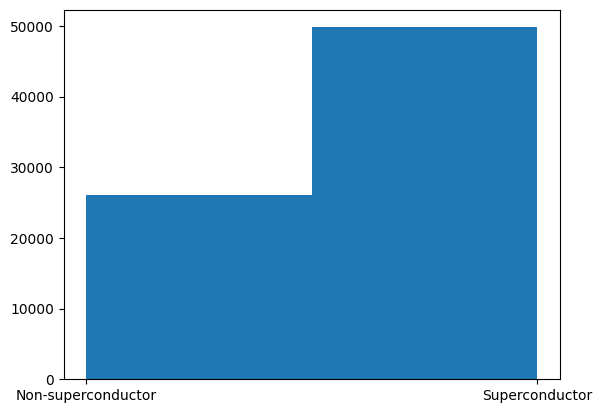

In [17]:
labels = [g.y.item() for g in graphs]

plt.hist(labels,bins=2)
plt.xticks([0, 1], ['Non-superconductor', 'Superconductor'])

## Attempt at data split

We have a lot of graphs (70k) but many are synth doped variants. We must split these to ensure that there is no overlap in the train/val/test dataloaders, which would lead to the model simply recognising these.

In [18]:
import re

def get_base_compound(cif_name):
    # Extract ICSD number as group identifier
    match = re.search(r'ICSD-(\d+)', cif_name)
    if match:
        return match.group(1)
    # For non-doped structures, use the full name without composition
    return cif_name.split('-')[0]

data['base_compound'] = data['cif'].apply(get_base_compound)
print(f"Unique base compounds: {data['base_compound'].nunique()}")
print(f"Total structures: {len(data)}")

Unique base compounds: 7746
Total structures: 75850


In [19]:
# Splitting by base compound
from sklearn.model_selection import train_test_split
import numpy as np

# Get unique base compounds
compounds = data['base_compound'].unique()

# Split compounds into train/val/test
train_compounds, test_compounds = train_test_split(compounds, test_size=0.2, random_state=429)
train_compounds, val_compounds  = train_test_split(train_compounds, test_size=0.2, random_state=65)

print(f"Train compounds: {len(train_compounds)}")
print(f"Val compounds:   {len(val_compounds)}")
print(f"Test compounds:  {len(test_compounds)}")

# Convert to sets for fast lookup
train_set = set(train_compounds)
val_set   = set(val_compounds)
test_set  = set(test_compounds)

# Split graphs using the same base_compound grouping
# Assumes graphs are in same order as data
train_graphs, val_graphs, test_graphs = [], [], []
for g, (_, row) in zip(graphs, data.iterrows()):
    compound = get_base_compound(row['cif'])
    if compound in train_set:
        train_graphs.append(g)
    elif compound in val_set:
        val_graphs.append(g)
    else:
        test_graphs.append(g)

print(f"Train graphs: {len(train_graphs)}")
print(f"Val graphs:   {len(val_graphs)}")
print(f"Test graphs:  {len(test_graphs)}")

# Verify no overlap
train_cifs = set(data[data['base_compound'].isin(train_set)]['cif'])
test_cifs  = set(data[data['base_compound'].isin(test_set)]['cif'])
print(f"Overlap between train and test: {len(train_cifs & test_cifs)}")


total = len(train_graphs) + len(val_graphs) + len(test_graphs)
print(f"Train: {len(train_graphs)} ({100*len(train_graphs)/total:.1f}%)")
print(f"Val:   {len(val_graphs)}   ({100*len(val_graphs)/total:.1f}%)")
print(f"Test:  {len(test_graphs)}  ({100*len(test_graphs)/total:.1f}%)")

real_test_graphs = [g for g, (_, row) in zip(test_graphs,
                    data[data['base_compound'].isin(test_set)].iterrows())
                    if 'synth' not in row['cif']]
print(f"Real test structures: {len(real_test_graphs)}")

Train compounds: 4956
Val compounds:   1240
Test compounds:  1550
Train graphs: 47691
Val graphs:   13032
Test graphs:  15127
Overlap between train and test: 0
Train: 47691 (62.9%)
Val:   13032   (17.2%)
Test:  15127  (19.9%)
Real test structures: 1094


# Model

In [20]:
def draw_crystal_graph(data, structure, title="Crystal Graph"):

    # Build networkx graph
    G = nx.Graph()

    # Add nodes
    num_atoms = data.x.shape[0]
    for i in range(num_atoms):
        G.add_node(i)

    # Add edges (avoid duplicate edges since graph is undirected)
    edge_index = data.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        if src < dst:  # avoid duplicates
            G.add_edge(src, dst)

    # Get atom labels and colors for each node
    labels = {}
    colors = []
    color_map = {}  # map element symbol to color
    cmap = plt.cm.get_cmap("tab20")
    color_idx = 0

    for i, site in enumerate(structure):
        if site.is_ordered:
            symbol = site.specie.symbol
        else:
            # Use dominant element for label
            symbol = max(site.species, key=site.species.get).symbol
            symbol = symbol + "*"  # mark doped sites with asterisk

        labels[i] = symbol

        if symbol not in color_map:
            color_map[symbol] = cmap(color_idx % 20)
            color_idx += 1
        colors.append(color_map[symbol])

    # Draw
    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="white", ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10, label=symbol)
        for symbol, color in color_map.items()
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    ax.set_title(f"{title}\n{data.x.shape[0]} atoms, {G.number_of_edges()} bonds, Tc={data.y.item():.1f} K")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [21]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
import numpy as np

class CGCNN(nn.Module):
    def __init__(self, node_features=8, edge_features=40,
                 hidden_dim=64, num_conv_layers=3, dropout=0.1):
        super(CGCNN, self).__init__()

        # Initial embedding of node features
        self.node_embedding = nn.Linear(node_features, hidden_dim)

        # Graph convolutional layers
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim, dim=edge_features, batch_norm=True)
            for _ in range(num_conv_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        # Readout MLP
        self.fc = nn.Sequential(
            # nn.Linear(hidden_dim, hidden_dim // 2),
            # nn.ReLU(),
            # nn.Dropout(dropout),
            # nn.Linear(hidden_dim // 2, 1),
            # nn.Sigmoid()
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        # Embed node features
        x = self.node_embedding(x)
        x = torch.relu(x)

        # Graph convolutions
        for conv in self.conv_layers:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
            x = self.dropout(x)

        # Global pooling: aggregate all atoms into one vector
        x = global_mean_pool(x, batch)

        # Predict
        out = self.fc(x)
        return out.squeeze(-1)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)

        y = batch.y.view(-1)  # flatten to 1D

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)

            # Use squeeze(-1) to only squeeze the last dimension
            y = batch.y.view(-1).float()  # flatten to 1D regardless of shape

            loss = criterion(pred, y)
            total_loss += loss.item()
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())

    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))
    return total_loss / len(loader), mae


cpu
Train: 47691 | Val: 13032 | Test: 15127
Epoch   0 | Train Loss: 0.6075 | Val Loss: 0.6134
Epoch  10 | Train Loss: 0.4615 | Val Loss: 0.5227
Epoch  20 | Train Loss: 0.4416 | Val Loss: 0.5138
Epoch  30 | Train Loss: 0.4274 | Val Loss: 0.4962
Epoch  40 | Train Loss: 0.4209 | Val Loss: 0.4781
Epoch  50 | Train Loss: 0.4077 | Val Loss: 0.4508
Epoch  60 | Train Loss: 0.4012 | Val Loss: 0.4622
Epoch  70 | Train Loss: 0.4024 | Val Loss: 0.4319
Epoch  80 | Train Loss: 0.3888 | Val Loss: 0.4444
Epoch  90 | Train Loss: 0.3869 | Val Loss: 0.4126
Epoch 100 | Train Loss: 0.3766 | Val Loss: 0.4217
Epoch 110 | Train Loss: 0.3574 | Val Loss: 0.4275
Epoch 120 | Train Loss: 0.3522 | Val Loss: 0.4157
Epoch 130 | Train Loss: 0.3486 | Val Loss: 0.4050
Epoch 140 | Train Loss: 0.3511 | Val Loss: 0.4286
Epoch 150 | Train Loss: 0.3462 | Val Loss: 0.3952
Epoch 160 | Train Loss: 0.3452 | Val Loss: 0.4079
Epoch 170 | Train Loss: 0.3338 | Val Loss: 0.4045
Epoch 180 | Train Loss: 0.3418 | Val Loss: 0.3986
Epoch 

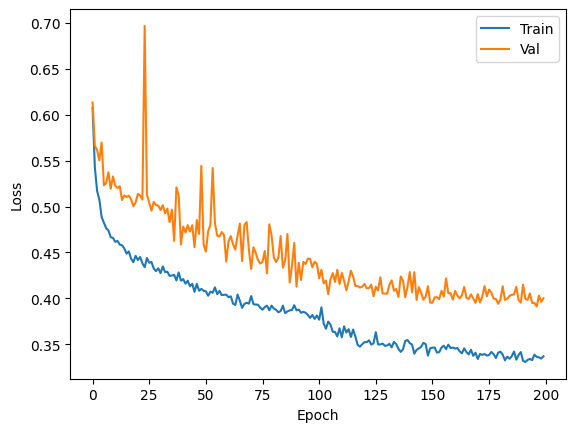

In [32]:
# train
from sklearn.model_selection import train_test_split

# graphs = torch.load('classifier_crystal_graphs.pt', weights_only=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# # Split
# train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
# train_graphs, val_graphs  = train_test_split(train_graphs, test_size=0.2, random_state=42)

# # Class imbalance weight
labels = [g.y.item() for g in train_graphs]
n_neg, n_pos = labels.count(0), labels.count(1)
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
pos_weight = torch.tensor([1.0]).to(device) # For weighted sampling
print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")
# print(f"Pos weight: {pos_weight.item():.2f}")

# Loaders

from torch.utils.data import WeightedRandomSampler

# train_weights = torch.tensor([g.weight.item() for g in train_graphs])
# sampler = WeightedRandomSampler(
#     weights=train_weights,
#     num_samples=len(train_graphs),
#     replacement=True
# )

# train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader  = DataLoader(val_graphs,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)
real_test_loader = DataLoader(real_test_graphs, batch_size=32, shuffle=False)

# Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
node_features = train_graphs[0].x.shape[1]
cgcnn_c_v1 = CGCNN(node_features=node_features, edge_features=40, hidden_dim=16, num_conv_layers=2, dropout=0.3).to(device)

# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# To include reduction with weights:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')

optimizer = torch.optim.Adam(cgcnn_c_v1.parameters(), lr=1e-3)
# scheduler = StepLR(optimizer, step_size=50, gamma=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

# Training loop
epochs = 200
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_counter = 20, 0

for epoch in range(epochs):
    # Train
    cgcnn_c_v1.train()
    total_loss = 0
    for batch in train_loader:
        # batch = batch.to(device)
        # optimizer.zero_grad()
        # pred = cgcnn_c_v1(batch).squeeze(-1)
        # loss = criterion(pred, batch.y.view(-1).float())
        # loss.backward()
        # optimizer.step()
        # total_loss += loss.item()

        batch = batch.to(device)
        optimizer.zero_grad()
        pred = cgcnn_c_v1(batch).squeeze(-1)
        loss_per_sample = criterion(pred, batch.y.view(-1).float())  # now returns per-sample losses
        weights = batch.weight.view(-1).to(device)
        weights = weights / weights.sum() * len(weights)  # normalise
        loss = (loss_per_sample * weights).mean()

        loss.backward()
        optimizer.step()
        total_loss += loss.item()


    train_loss = total_loss / len(train_loader)

    # Validate
    cgcnn_c_v1.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            # batch = batch.to(device)
            # pred = cgcnn_c_v1(batch).squeeze(-1)
            # loss = criterion(pred, batch.y.view(-1).float())
            # total_val_loss += loss.item()
            batch = batch.to(device)
            pred = cgcnn_c_v1(batch).squeeze(-1)
            loss = criterion(pred, batch.y.view(-1).float()).mean()
            total_val_loss += loss.item()

    val_loss = total_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    # scheduler.step()
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cgcnn_c_v1.state_dict(), 'cgcnn_classifier_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Loss curve
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

In [67]:
# Test evaluation
from sklearn.metrics import classification_report, confusion_matrix
real_test_loader = DataLoader(real_test_graphs, batch_size=32, shuffle=False)

all_preds, all_targets = [], []
cgcnn_c_v1.eval()
with torch.no_grad():
    for batch in real_test_loader:
        batch = batch.to(device)
        prob = torch.sigmoid(cgcnn_c_v1(batch)).squeeze(-1)
        all_preds.extend(prob.cpu().numpy())
        all_targets.extend(batch.y.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets).astype(int)
binary_preds = (all_preds > 0.6).astype(int)

print(classification_report(all_targets, binary_preds, target_names=['Non-SC', 'SC']))
print(confusion_matrix(all_targets, binary_preds))

              precision    recall  f1-score   support

      Non-SC       0.95      0.96      0.96       979
          SC       0.64      0.58      0.61       115

    accuracy                           0.92      1094
   macro avg       0.79      0.77      0.78      1094
weighted avg       0.92      0.92      0.92      1094

[[941  38]
 [ 48  67]]


In [37]:
# Save
torch.save(cgcnn_c_v1.state_dict(), '/content/ML_Personal_git/cgcnn_classifier_ICSD_7K.pt')
np.savetxt('/content/ML_Personal_git/cgcnn_classifier_preds_ICSD_7K.csv',   all_preds)
np.savetxt('/content/ML_Personal_git/cgcnn_classifier_targets_ICSD_7K.csv', all_targets)

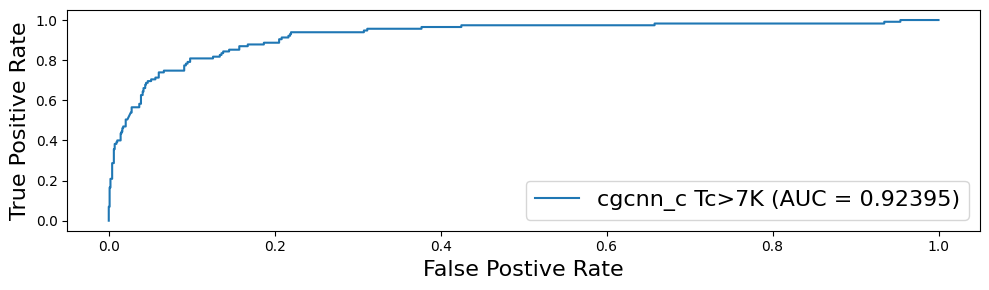

In [68]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(all_targets,all_preds)
auc_score = auc(fpr,tpr)
fig = plt.figure(figsize = [10,3])
plt.plot(fpr, tpr, label=f'cgcnn_c Tc>7K (AUC = {auc_score:5.5f})')
plt.legend(fontsize=16)
plt.xlabel('False Postive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.tight_layout()
fig.savefig("/content/ML_Personal_git/roc_cgcnn_ICSD.png")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(all_targets, all_preds)
plt.plot(recall, precision)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.show()

In [ ]:
target_recall = 0.75
idx = np.argmin(np.abs(recall - target_recall))
print(f"Threshold: {thresholds[idx]:.3f}, Precision: {precision[idx]:.3f}")

In [ ]:
total_params = sum(p.numel() for p in cgcnn_c_v1.parameters())
trainable_params = sum(p.numel() for p in cgcnn_c_v1.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Perm importance:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from sklearn.model_selection import train_test_split

train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs  = train_test_split(train_graphs, test_size=0.2, random_state=42)

from torch.utils.data import WeightedRandomSampler

train_weights = torch.tensor([g.weight.item() for g in train_graphs])
sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_graphs),
    replacement=True
)

train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler)
val_loader  = DataLoader(val_graphs,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)


node_features = train_graphs[0].x.shape[1]
model = CGCNN(node_features=node_features, edge_features=40, hidden_dim=16, num_conv_layers=2, dropout=0.3).to(device)

model.load_state_dict(torch.load(path+'/cgcnn_classifier_hot_7K.pt', map_location=device))
model.eval()

In [ ]:
from pymatgen.core import Element
correct_symbols = [Element.from_Z(z).symbol for z in range(1, 95)]
print(f"Correct length: {len(correct_symbols)}")
print(set(correct_symbols) - set(ELEMENT_SYMBOLS))  # find missing ones

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# ── Feature names (117 total) ─────────────────────────────────────────────────
ELEMENT_SYMBOLS = [Element.from_Z(z).symbol for z in range(1, MAX_Z + 1)]
# 94 one-hot features

SCALAR_FEATURES = [
    'atomic_mass', 'atomic_radius', 'ionic_radius', 'electronegativity',
    'max_ox_state', 'min_ox_state', 'ox_state', 'ox_range',  # 8 scalar elemental
    'occupancy', 'disorder',                                  # 2 site
    'frac_x', 'frac_y', 'frac_z',                            # 3 fractional coords
    'coordination_number',                                    # 1
    'op_cn', 'op_tet', 'op_oct', 'op_sq', 'op_bent',         # 5 order params
    'voronoi_volume', 'mean_solid_angle', 'std_solid_angle', 'mean_face_area',  # 4 Voronoi
]  # 23 scalar features
SCALAR_FEATURES = [
    'atomic_mass', 'atomic_radius', 'ionic_radius', 'molar_volume',
    'electronegativity', 'max_ox_state', 'min_ox_state', 'ox_state', 'ox_range',
    'valence_electrons', 'd_electrons', 'is_d_block', 'is_f_block', 'mendeleev_no',
    'occupancy', 'disorder',
    'frac_x', 'frac_y', 'frac_z',
    'coordination_number',
    'op_cn', 'op_tet', 'op_oct', 'op_sq', 'op_bent',
    'voronoi_volume', 'mean_solid_angle', 'std_solid_angle', 'mean_face_area',
]  # 29 scalar features → total node features = 94 + 29 = 123

FEATURE_NAMES = ELEMENT_SYMBOLS + SCALAR_FEATURES  # 117 total

# ── Helper functions ──────────────────────────────────────────────────────────
def get_graph_feature_matrix(graphs):
    return np.array([g.x.numpy().mean(axis=0) for g in graphs])

def predict_from_features(feature_matrix, graphs, model, device, batch_size=64):
    preds = []
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feat_tensor = torch.tensor(feature_matrix, dtype=torch.float32)
    idx = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            bs = batch.num_graphs
            sizes    = batch.ptr[1:] - batch.ptr[:-1]
            expanded = torch.repeat_interleave(feat_tensor[idx:idx+bs].to(device), sizes, dim=0)
            batch.x  = expanded
            pred     = torch.sigmoid(model(batch))  # probabilities for classifier
            preds.extend(pred.cpu().numpy().flatten())
            idx += bs
    return np.array(preds)

# ── Permutation importance (AUC drop) ────────────────────────────────────────
def permutation_importance_auc(model, graphs, device, n_repeats=10, batch_size=64):
    model.eval()
    X = get_graph_feature_matrix(graphs)
    y = np.array([g.y.item() for g in graphs])

    baseline_auc = roc_auc_score(y, predict_from_features(X, graphs, model, device, batch_size))
    print(f"Baseline AUC: {baseline_auc:.4f}")

    n_features  = X.shape[1]
    importances = np.zeros((n_features, n_repeats))

    for f in range(n_features):
        for r in range(n_repeats):
            X_perm       = X.copy()
            X_perm[:, f] = np.random.permutation(X_perm[:, f])
            preds        = predict_from_features(X_perm, graphs, model, device, batch_size)
            importances[f, r] = baseline_auc - roc_auc_score(y, preds)
        print(f"  feature {f+1:03d}/{n_features} done", end="\r")

    print()
    return {"mean": importances.mean(axis=1), "std": importances.std(axis=1),
            "baseline_auc": baseline_auc, "raw": importances}

# ── Plot (top N, one-hot elements collapsed to a single bar) ──────────────────
def plot_importance(perm_result, feature_names=FEATURE_NAMES, top_n=20):
    means = perm_result["mean"]
    stds  = perm_result["std"]

    # Collapse all 94 one-hot element features into one representative score
    n_onehot = 94  # MAX_Z, hardcoded to match model

    onehot_importance = means[:n_onehot].mean()
    onehot_std        = means[:n_onehot].std()

    collapsed_names = np.array(["element_identity (one-hot)"] + SCALAR_FEATURES)
    collapsed_means = np.concatenate([[onehot_importance], means[n_onehot:]])
    collapsed_stds  = np.concatenate([[onehot_std],        stds[n_onehot:]])

    order  = np.argsort(collapsed_means)[-top_n:]
    names  = [collapsed_names[i] for i in order]
    m_vals = collapsed_means[order]
    s_vals = collapsed_stds[order]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(names, m_vals, xerr=s_vals, capsize=3, color="#378ADD", alpha=0.85, ecolor="#888780")
    ax.axvline(0, color="#888780", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Drop in AUC after permutation (higher = more important)")
    ax.set_title(f"Permutation importance — classifier (top {top_n})")
    ax.text(0.98, 0.02, f"Baseline AUC: {perm_result['baseline_auc']:.4f}",
            transform=ax.transAxes, ha="right", fontsize=9, color="#888780")
    plt.tight_layout()
    plt.savefig("permutation_importance_classifier.png", dpi=150)
    plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
perm_result = permutation_importance_auc(model, test_graphs, device, n_repeats=10)
plot_importance(perm_result)

# Numeric summary (scalar features only, sorted)
print("\nTop scalar features:")
scalar_means = perm_result["mean"][94:]
order = np.argsort(scalar_means)[::-1]
for rank, i in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {SCALAR_FEATURES[i]:<25s}  {scalar_means[i]:+.4f} ± {perm_result['std'][94+i]:.4f}")

In [ ]:
print(f"FEATURE_NAMES length: {len(FEATURE_NAMES)}")
print(f"ELEMENT_SYMBOLS length: {len(ELEMENT_SYMBOLS)}")
print(f"SCALAR_FEATURES length: {len(SCALAR_FEATURES)}")
print(f"perm_result mean length: {len(perm_result['mean'])}")
print(f"collapsed_names length: {len(['element_identity (one-hot)'] + list(FEATURE_NAMES[94:]))}")

## Comparing to 3dsc MP

In [45]:
data_MP = pd.read_csv('/content/3DSC/superconductors_3D/data/final/MP/3DSC_MP.csv',skiprows=1)

unique_MP_ids = np.where(~np.isin(data_MP['formula_sc'],data['formula_sc']))[0]
print(len(data_MP),len(unique_MP_ids))


5773 771


In [47]:
data_MP_unique = data_MP[~np.isin(data_MP['formula_sc'],data['formula_sc'])]

In [53]:
data_MP_unique.reset_index(drop=True, inplace=True)
data_MP_unique.at[0,'cif']

'data/final/MP/cifs/Ag0.438Hg0.562-MP-mp-758523-synth_doped.cif'

In [56]:
# Generate new graphs, if they are not found in ICSD
from pymatgen.core import Structure
from tqdm import tqdm


graphs_MP = []
for i, row in tqdm(data_MP_unique.iterrows(), total=len(data_MP_unique), desc="Building MP graphs"):
    try:
        path_cif = '/content/3DSC/superconductors_3D/'+row['cif']
        structure = Structure.from_file(path_cif)
        target = row['tc']
        graph = structure_to_graph_adaptive(structure, target=target,use_env=True)
        graph.weight = torch.tensor([row['weight']], dtype=torch.float)
        graphs_MP.append(graph)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

print(f"Built {len(graphs_MP)} graphs")
print(graphs_MP[0])  # inspect first graph

Building MP graphs:   1%|▏         | 11/771 [00:19<29:40,  2.34s/it]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Building MP graphs:   2%|▏         | 13/771 [00:20<16:27,  1.30s/it]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Building MP graphs:   2%|▏         | 15/771 [00:21<13:33,  1.08s/it]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primiti

Built 771 graphs
Data(x=[8, 123], edge_index=[2, 104], edge_attr=[104, 40], y=[1], weight=[1])


In [57]:
graph_path = '/classifier_crystal_graphs_testMP.pt'

torch.save(graphs, path + graph_path)
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(path + graph_path, "/content/drive/MyDrive/ML_models"+graph_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/ML_models/classifier_crystal_graphs_testMP.pt'

In [59]:
graphs_MP = torch.load("/content/drive/MyDrive/ML_models"+graph_path,weights_only=False)

In [60]:
tc_min = 7
for g, (_, row) in zip(graphs_MP, data.iterrows()):
    g.y = torch.tensor([1.0 if row['tc'] >= tc_min else 0.0])

In [64]:
#test on MP with model
testMP_loader = DataLoader(graphs_MP, batch_size=32, shuffle=False)
# Test evaluation
from sklearn.metrics import classification_report, confusion_matrix

all_preds_MP, all_targets_MP = [], []
cgcnn_c_v1.eval()
with torch.no_grad():
    for batch in testMP_loader:
        batch = batch.to(device)
        prob = torch.sigmoid(cgcnn_c_v1(batch)).squeeze(-1)
        all_preds_MP.extend(prob.cpu().numpy())
        all_targets_MP.extend(batch.y.cpu().numpy())

all_preds_MP   = np.array(all_preds_MP)
all_targets_MP = np.array(all_targets_MP).astype(int)
binary_preds_MP = (all_preds_MP > 0.6).astype(int)

print(classification_report(all_targets_MP, binary_preds_MP, target_names=['Non-SC', 'SC']))
print(confusion_matrix(all_targets_MP, binary_preds_MP))


              precision    recall  f1-score   support

      Non-SC       0.91      0.58      0.71     26028
          SC       0.81      0.97      0.89     49822

    accuracy                           0.84     75850
   macro avg       0.86      0.77      0.80     75850
weighted avg       0.85      0.84      0.82     75850

[[15011 11017]
 [ 1496 48326]]


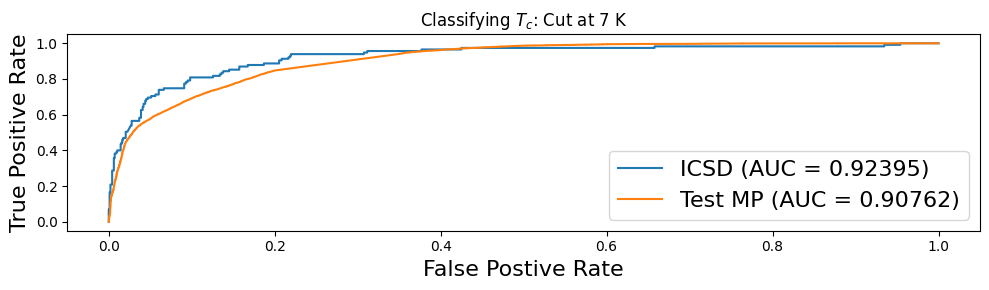

In [75]:
from sklearn.metrics import roc_curve, auc
fpr_MP, tpr_MP, _ = roc_curve(all_targets_MP,all_preds_MP)
auc_score_MP = auc(fpr_MP,tpr_MP)
fig = plt.figure(figsize = [10,3])
plt.title(f'Classifying $T_c$: Cut at 7 K')
plt.plot(fpr, tpr, label=f'ICSD (AUC = {auc_score:5.5f})')
plt.plot(fpr_MP, tpr_MP, label=f'Test MP (AUC = {auc_score_MP:5.5f})')
plt.legend(fontsize=16)
plt.xlabel('False Postive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.tight_layout()
fig.savefig("/content/ML_Personal_git/roc_cgcnn_testMP.png")
plt.show()



For pushing to git:

In [ ]:
import os
os.chdir("/content/ML_Personal_git")  # move into repo FIRST
token = "MY_TOKEN"

!git remote set-url origin https://{token}@github.com/SSBNS/ML_Personal_git.git

In [ ]:
!git status

In [ ]:
# import os
# os.chdir("/content/ML_Personal_git")  # make sure you're in the repo folder
!git add .
# !git add "3DSC_looker.ipynb"

In [ ]:
!git commit -m "Add results from Colab"
!git push

In [ ]:
!git reset HEAD^
!git push

In [ ]:
!Add-Content .gitignore "classifier_crystal_graphs_v2.pt"
!git add .gitignore
!git commit -m "Ignore large model files"
!git push